# DenseNet-121 Inference + Grad-CAM 

In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import pickle
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

## Setup

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Reload Dataset Objects (val_loader only)

# load apply_clahe and circular_crop so pickle finds them
def apply_clahe(img, **kwargs):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    enhanced_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return enhanced_img

def circular_crop(img, **kwargs):
    h, w, _ = img.shape
    center = (w//2, h//2)
    r = min(center[0], center[1], w-center[0], h-center[1])
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X-center[0])**2 + (Y-center[1])**2)
    mask = dist <= r
    cropped = np.zeros_like(img)
    cropped[mask] = img[mask]
    return cv2.resize(cropped, (320, 320))

# load APTOSDataset so pickle can load the objects
class APTOSDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_id = self.dataframe.loc[idx, 'id_code']
        label = int(self.dataframe.loc[idx, 'diagnosis'])
        img_path = os.path.join(self.img_dir, f"{img_id}.png")

        image = np.array(Image.open(img_path).convert('RGB'))

        if self.transform:
            image = self.transform(image=image)['image']

        return image, torch.tensor(label, dtype=torch.long)

# Load dataloaders
with open("../data/processed/loaders.pkl", "rb") as f:
    data_objects = pickle.load(f)

val_loader = data_objects["val_loader"]
print("Loaded val_loader:", len(val_loader))

Using device: cuda
Loaded val_loader: 23


## Load Trained DenseNet-121 Checkpoint

In [3]:
from torchvision.models import densenet121

# 1. Recreate the DenseNet-121 architecture
model = densenet121(weights=None)      # No pretrained weights
model.classifier = nn.Linear(model.classifier.in_features, 5)

model = model.to(device)
model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [4]:
checkpoint_path = "../models/best_densenet121_320.pth"

state_dict = torch.load(checkpoint_path, map_location=device)

# Clean keys if trained under DataParallel
new_state_dict = {}
for k, v in state_dict.items():
    new_state_dict[k.replace("module.", "")] = v

model.load_state_dict(new_state_dict)
print("DenseNet-121 checkpoint loaded successfully!")

DenseNet-121 checkpoint loaded successfully!


## Run Inference

Running Inference:   0%|          | 0/23 [00:00<?, ?it/s]

Running Inference: 100%|██████████| 23/23 [00:46<00:00,  2.00s/it]


===== DenseNet-121 Metrics =====
Accuracy:            0.7735
Precision (macro):   0.5974
Recall (macro):      0.6041
F1-score (macro):    0.5932
Balanced Accuracy:   0.6041

Classification Report:

              precision    recall  f1-score   support

           0     0.9775    0.9640    0.9707       361
           1     0.5106    0.3243    0.3967        74
           2     0.7059    0.7200    0.7129       200
           3     0.2931    0.4359    0.3505        39
           4     0.5000    0.5763    0.5354        59

    accuracy                         0.7735       733
   macro avg     0.5974    0.6041    0.5932       733
weighted avg     0.7814    0.7735    0.7744       733



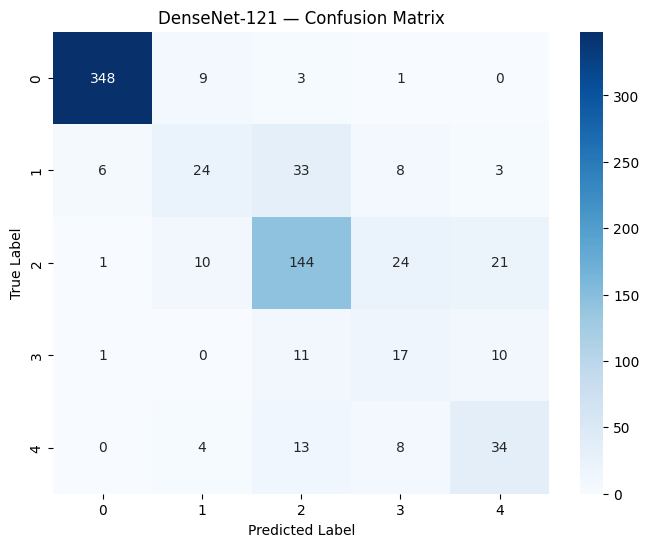

In [5]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, balanced_accuracy_score, confusion_matrix, classification_report
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ------------------------------
# Run Inference
# ------------------------------
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc="Running Inference"):
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ------------------------------
# Metrics
# ------------------------------
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec  = recall_score(y_true, y_pred, average='macro')
f1   = f1_score(y_true, y_pred, average='macro')
bacc = balanced_accuracy_score(y_true, y_pred)

print("===== DenseNet-121 Metrics =====")
print(f"Accuracy:            {acc:.4f}")
print(f"Precision (macro):   {prec:.4f}")
print(f"Recall (macro):      {rec:.4f}")
print(f"F1-score (macro):    {f1:.4f}")
print(f"Balanced Accuracy:   {bacc:.4f}")
print("=====================================\n")

# Full Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, digits=4))

# ------------------------------
# Confusion Matrix
# ------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3,4],
            yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("DenseNet-121 — Confusion Matrix")
plt.show()

## Grad-CAM Implementation

In [17]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class=None):
        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1)

        loss = output[:, target_class]
        self.model.zero_grad()
        loss.backward(retain_graph=True)

        pooled_grads = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations[0]

        for i in range(len(pooled_grads)):
            activations[i] *= pooled_grads[i]

        heatmap = torch.mean(activations, dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap /= heatmap.max()

        return heatmap

# Use last conv layer of DenseNet features
target_layer = model.features[-1]
gradcam = GradCAM(model, target_layer)

print("Grad-CAM Ready")


Grad-CAM Ready


## Grad-CAM Visualization on Sample Images

🩺 Grad-CAM for Image: e6a6acf7fca1


/home/myid/rm98243/miniconda3/envs/aptos-env/lib/python3.10/site-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


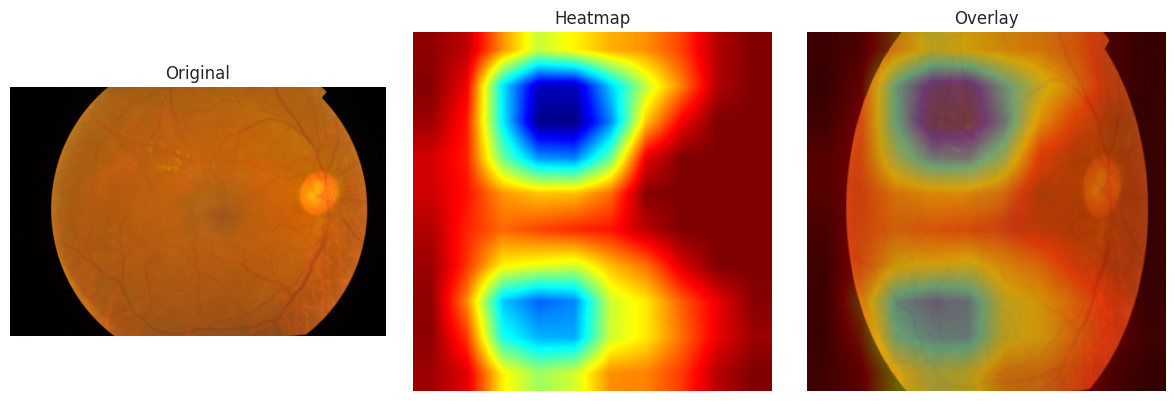

🩺 Grad-CAM for Image: 61ac9b0dc6b9


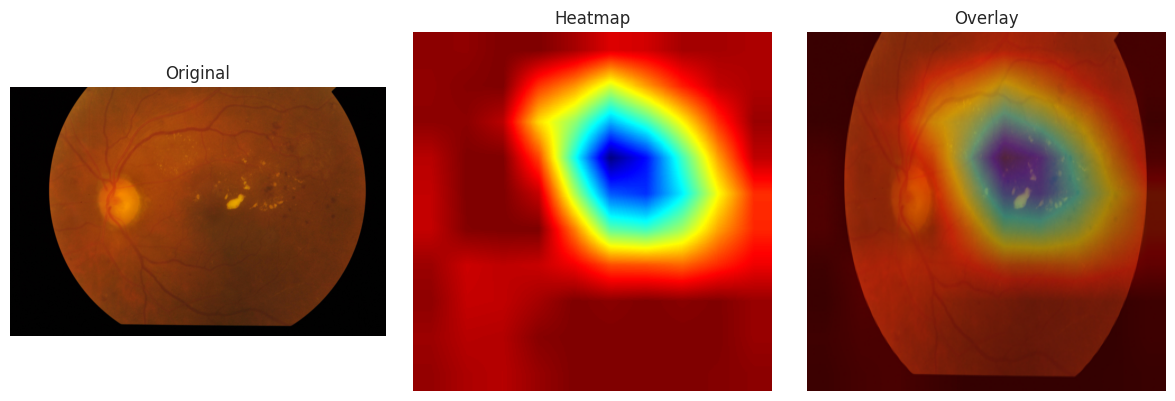

🩺 Grad-CAM for Image: 74eee788edee


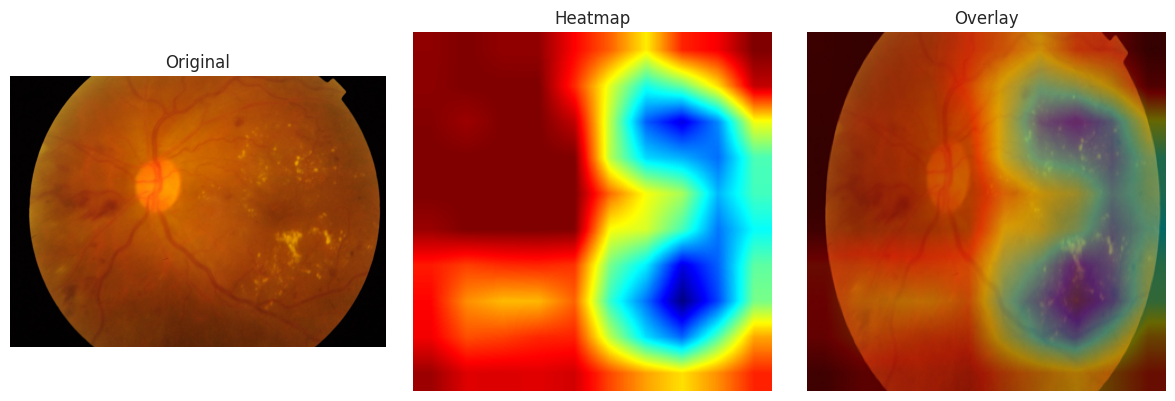

In [18]:
val_df = pd.read_csv("../data/raw/train.csv")
from sklearn.model_selection import train_test_split
_, val_df = train_test_split(val_df, test_size=0.2, stratify=val_df['diagnosis'], random_state=42)

sample_ids = val_df.sample(3, random_state=42)["id_code"].values
img_dir = "../data/raw/train_images/"

def show_gradcam(img_path):
    img = Image.open(img_path).convert("RGB")
    img_resized = img.resize((320, 320))

    preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406],
                             std=[0.229,0.224,0.225])
    ])

    tensor = preprocess(img_resized).unsqueeze(0).to(device)
    heatmap = gradcam.generate(tensor)

    heatmap = cv2.resize(heatmap, (320,320))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(np.array(img_resized), 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap)
    plt.title("Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

for img_id in sample_ids:
    print(f"🩺 Grad-CAM for Image: {img_id}")
    show_gradcam(os.path.join(img_dir, f"{img_id}.png"))